<a href="https://colab.research.google.com/github/toanhuynh040805-crypto/DeepLearning_DuDoanGiaNha/blob/main/THDeepLearning_DT2_Nhom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

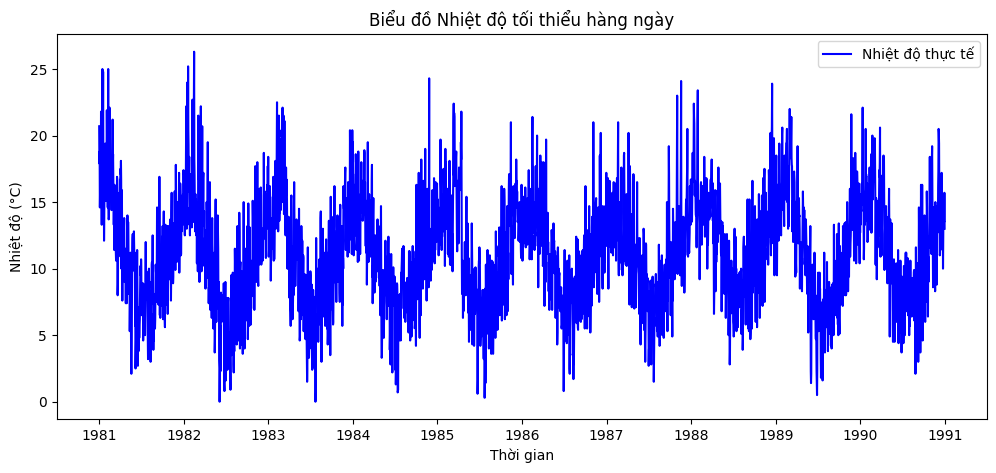

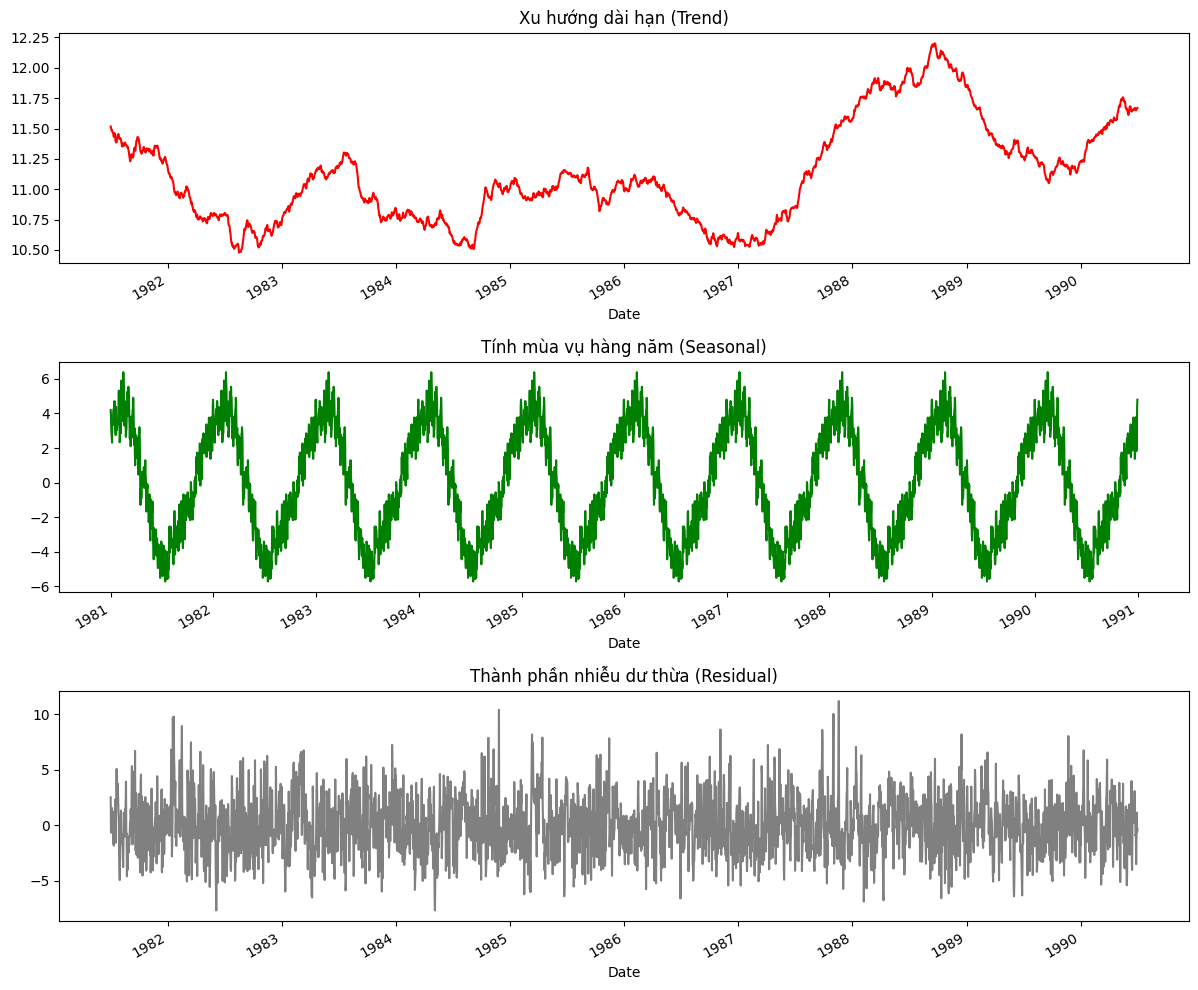

In [ ]:
#Đọc, xử lý dữ liệu lỗi và Trực quan hóa dữ liệu gốc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Đọc dữ liệu từ đường dẫn chính xác trong thư mục sample_data của bạn
# Cột đầu tiên là Ngày (Date), cột thứ 2 là Nhiệt độ (Daily minimum temperatures)
df = pd.read_csv('sample_data/daily-minimum-temperatures-in-me.csv', on_bad_lines='skip')

# 2. Đổi tên cột cho ngắn gọn và dễ thao tác
df.columns = ['Date', 'Temp']

# 3. Xử lý dữ liệu lỗi: Ép kiểu cột Temp sang số (float).
# Những giá trị lỗi ký tự không ép kiểu được sẽ thành NaN (errors='coerce')
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')

# 4. Xử lý giá trị thiếu (NaN) bằng phương pháp nội suy (interpolate) - rất tối ưu cho chuỗi thời gian
df['Temp'] = df['Temp'].interpolate(method='linear')

# 5. Chuyển cột Date về dạng datetime và đặt làm Index
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']) # Loại bỏ dòng nếu ngày bị lỗi
df.set_index('Date', inplace=True)

# 6. Trực quan hóa dữ liệu gốc
plt.figure(figsize=(12, 5))
plt.plot(df['Temp'], color='blue', label='Nhiệt độ thực tế')
plt.title('Biểu đồ Nhiệt độ tối thiểu hàng ngày')
plt.xlabel('Thời gian')
plt.ylabel('Nhiệt độ (°C)')
plt.legend()

# Phân rã chuỗi thời gian dựa trên chu kỳ 1 năm (365 ngày)
result = seasonal_decompose(df['Temp'], model='additive', period=365)

# Trực quan hóa 3 thành phần: Xu hướng, Mùa vụ và Nhiễu
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))
result.trend.plot(ax=ax1, color='red', title='Xu hướng dài hạn (Trend)')
result.seasonal.plot(ax=ax2, color='green', title='Tính mùa vụ hàng năm (Seasonal)')
result.resid.plot(ax=ax3, color='gray', title='Thành phần nhiễu dư thừa (Residual)')
plt.tight_layout()
plt.show()

In [ ]:
#Chuẩn hóa dữ liệu bằng MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# 1. Lấy mảng giá trị nhiệt độ và reshape về dạng 2D (yêu cầu của MinMaxScaler)
dataset = df['Temp'].values.reshape(-1, 1)

# 2. Khởi tạo và tiến hành chuẩn hóa dữ liệu về khoảng [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = scaler.fit_transform(dataset)

print(print("Kích thước dữ liệu sau chuẩn hóa:", dataset_scaled.shape))

Kích thước dữ liệu sau chuẩn hóa: (3650, 1)
None


In [ ]:
##Tạo cấu trúc dữ liệu "Sliding Window" (Cửa sổ trượt)
# Hàm tạo tập dữ liệu X (đầu vào dạng cửa sổ) và y (nhãn dự đoán)
def create_dataset(sequence, look_back=7):
    X, y = [], []
    for i in range(len(sequence) - look_back):
        # Lấy 7 phần tử liên tiếp làm X
        window = sequence[i:(i + look_back), 0]
        X.append(window)
        # Lấy phần tử ngay sau cửa sổ đó làm nhãn y
        y.append(sequence[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 7
X, y = create_dataset(dataset_scaled, look_back)

# Phân chia dữ liệu: 80% để Train và 20% để Test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Keras RNN yêu cầu đầu vào 3D: [samples, time_steps, features]
# Ở đây: features = 1 (chỉ có 1 biến nhiệt độ), time_steps = 7 (look_back)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(print(f"Cấu trúc X_train: {X_train.shape}, y_train: {y_train.shape}"))

Cấu trúc X_train: (2914, 7, 1), y_train: (2914,)
None


In [ ]:
##Xây dựng mô hình SimpleRNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

# 1. Khởi tạo mô hình tuần tự
model = Sequential()

# KHẮC PHỤC CẢNH BÁO: Thêm lớp Input độc lập để định hình dữ liệu đầu vào
model.add(Input(shape=(look_back, 1)))

# 2. Thêm lớp SimpleRNN với 32 units (Bỏ tham số input_shape ở đây)
model.add(SimpleRNN(units=32))

# 3. Thêm lớp Dense để dự đoán giá trị tiếp theo
model.add(Dense(units=1))

# 4. Biên dịch mô hình với bộ tối ưu Adam và hàm mất mát MSE
model.compile(optimizer='adam', loss='mean_squared_error')

# Hiển thị bảng tóm tắt cấu trúc mạng
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0102 - val_loss: 0.0076
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - val_loss: 0.0073
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - val_loss: 0.0074
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0074
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0073
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0092 - val_loss: 0.0075
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0092 - val_loss: 0.0074
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0076
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0091 - val_loss: 0.0078
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0091 - val_loss: 0.0074
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0073
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0092 - val_lo

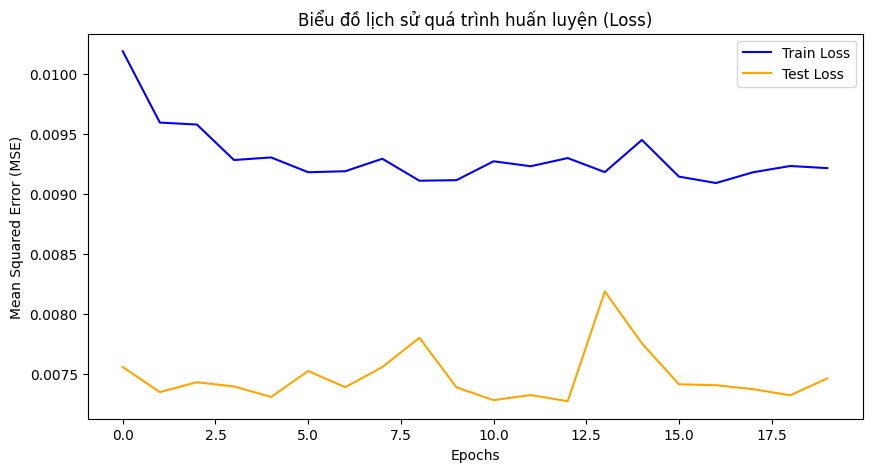

In [ ]:
#Huấn luyện mô hình và Vẽ biểu đồ Loss
# 1. Huấn luyện mô hình và lưu lịch sử (history) để vẽ biểu đồ
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# 2. Vẽ biểu đồ thể hiện sai số (Loss) của tập Train và Test
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Test Loss', color='orange')
plt.title('Biểu đồ lịch sử quá trình huấn luyện (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


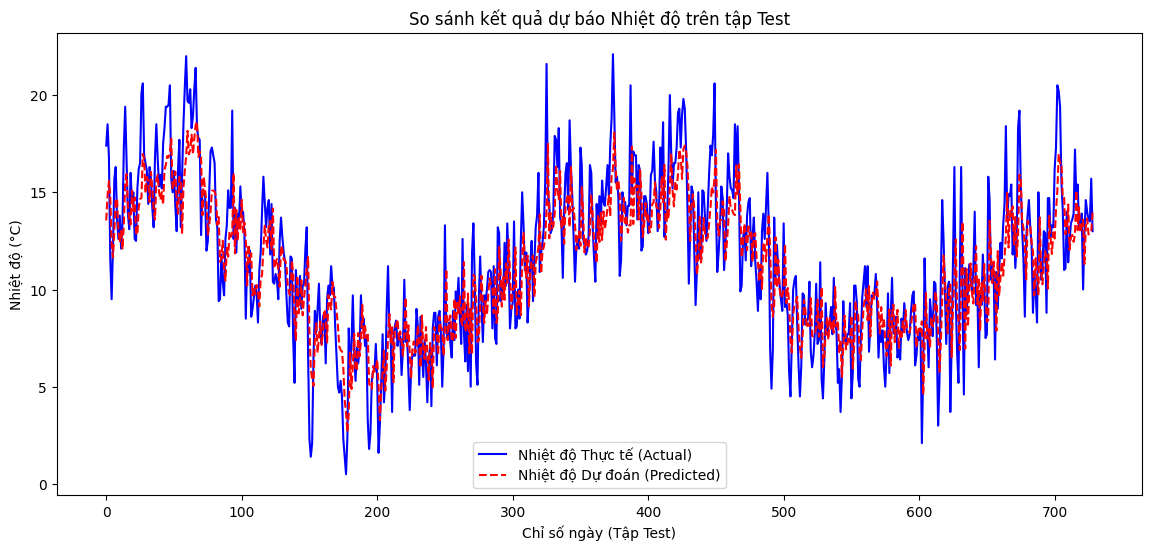

In [ ]:
#Dự báo, Nghịch đảo chuẩn hóa và So sánh kết quả
# 1. Thực hiện dự báo trên tập dữ liệu Test
predictions_scaled = model.predict(X_test)

# 2. Đảo ngược quá trình chuẩn hóa (Inverse Transform) cho cả giá trị dự đoán và giá trị thực tế
predictions = scaler.inverse_transform(predictions_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# 3. Vẽ biểu đồ so sánh trực quan giữa Giá trị thực tế và Giá trị dự đoán
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, color='blue', label='Nhiệt độ Thực tế (Actual)')
plt.plot(predictions, color='red', linestyle='--', label='Nhiệt độ Dự đoán (Predicted)')
plt.title('So sánh kết quả dự báo Nhiệt độ trên tập Test')
plt.xlabel('Chỉ số ngày (Tập Test)')
plt.ylabel('Nhiệt độ (°C)')
plt.legend()
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

====== BẢNG SỐ LIỆU ĐỐI CHỨNG DÙNG TRONG BÁO CÁO ======
        Chỉ số toán học Mô hình SimpleRNN Mô hình LSTM
 MAE (Sai số tuyệt đối)           1.79 °C      1.78 °C
RMSE (Sai số hiệu dụng)           2.27 °C      2.27 °C
    Hệ số tương quan R²            0.6937       0.6951


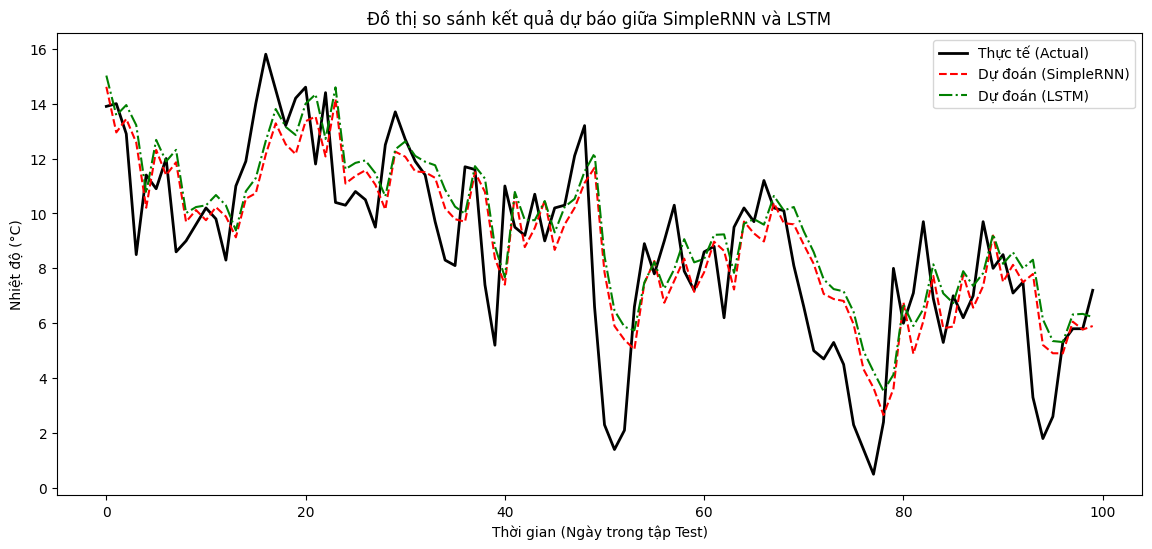

===== CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH =====
MAE  (Sai số tuyệt đối trung bình): 1.79 °C
RMSE (Căn sai số bình phương trung bình): 2.27 °C
R² Score (Hệ số xác định): 0.6937


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.layers import LSTM
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tính toán các chỉ số đo lường dựa trên giá trị thực tế và dự đoán đã nghịch đảo chuẩn hóa
mae = mean_absolute_error(y_test_real, predictions)
mse = mean_squared_error(y_test_real, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_real, predictions)

# 1. Khởi tạo và thiết lập kiến trúc mạng LSTM đối chứng
model_lstm = Sequential()
model_lstm.add(Input(shape=(look_back, 1)))
model_lstm.add(LSTM(units=32))
model_lstm.add(Dense(units=1))

# 2. Biên dịch mô hình
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# 3. Huấn luyện mô hình LSTM (ẩn tiến trình verbose để tập tin sạch sẽ hơn)
history_lstm = model_lstm.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=0)

# 4. Dự báo dữ liệu trên tập Test và thực hiện nghịch đảo chuẩn hóa về độ C
pred_lstm_scaled = model_lstm.predict(X_test)
pred_lstm = scaler.inverse_transform(pred_lstm_scaled)

# Tính toán chỉ số đánh giá của mô hình LSTM
mae_lstm = mean_absolute_error(y_test_real, pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, pred_lstm))
r2_lstm = r2_score(y_test_real, pred_lstm)

# Gom số liệu của cả 2 mô hình vào một bảng DataFrame
summary_df = pd.DataFrame({
    'Chỉ số toán học': ['MAE (Sai số tuyệt đối)', 'RMSE (Sai số hiệu dụng)', 'Hệ số tương quan R²'],
    'Mô hình SimpleRNN': [f"{mae:.2f} °C", f"{rmse:.2f} °C", f"{r2:.4f}"],
    'Mô hình LSTM': [f"{mae_lstm:.2f} °C", f"{rmse_lstm:.2f} °C", f"{r2_lstm:.4f}"]
})

print("\n====== BẢNG SỐ LIỆU ĐỐI CHỨNG DÙNG TRONG BÁO CÁO ======")
print(summary_df.to_string(index=False))

# Vẽ đồ thị so sánh trực quan một phân đoạn 100 ngày để thấy độ khớp
plt.figure(figsize=(14, 6))
plt.plot(y_test_real[100:200], color='black', label='Thực tế (Actual)', linewidth=2)
plt.plot(predictions[100:200], color='red', linestyle='--', label='Dự đoán (SimpleRNN)')
plt.plot(pred_lstm[100:200], color='green', linestyle='-.', label='Dự đoán (LSTM)')
plt.title('Đồ thị so sánh kết quả dự báo giữa SimpleRNN và LSTM')
plt.xlabel('Thời gian (Ngày trong tập Test)')
plt.ylabel('Nhiệt độ (°C)')
plt.legend()
plt.show()

# In kết quả ra màn hình để đưa vào báo cáo
print("===== CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH =====")
print(f"MAE  (Sai số tuyệt đối trung bình): {mae:.2f} °C")
print(f"RMSE (Căn sai số bình phương trung bình): {rmse:.2f} °C")
print(f"R² Score (Hệ số xác định): {r2:.4f}")